# CRISP-DM Phase 1: Business Understanding (ความเข้าใจบริบทและเป้าหมาย กทม.)
## Traffy Fondue Machine Learning: Standalone 3-Tier Pipeline
### ระบบ AI ครบวงจรพยากรณ์ระยะเวลาซ่อมแซมและจัดลำดับความสำคัญปัญหาเมือง กทม.
*(ฉบับ All-in-One: รวมโค้ดครบในไฟล์เดียว อ่านข้อมูลจากโฟลเดอร์ในเครื่อง 100% ไม่ต้องดึง API)*

---

### 1. บริบทและปัญหาของ กทม. (Business / City Context):
* ระบบ Traffy Fondue มีเรื่องร้องเรียนเข้ามาปีละกว่า 200,000 - 300,000 เรื่อง
* **แหล่งอ้างอิงชุดข้อมูลเปิด (BMA Open Data):** [https://data.bangkok.go.th/dataset/traffy-fondue](https://data.bangkok.go.th/dataset/traffy-fondue)
* **ปัญหาคิวงาน FIFO (มาก่อน-ได้ก่อน):** ปัญหาวิกฤตอันตรายถึงชีวิตต้องรอคิวปะปนกับปัญหาความสวยงาม
* **ไม่รู้ระยะเวลาซ่อมล่วงหน้า:** ประชาชนไม่ทราบว่าต้องรอกี่วัน เจ้าหน้าที่วางแผนอัตรากำลังคนข้ามเขตไม่ได้

### 2. เป้าหมายของโปรเจกต์ (Project Objectives):
* สร้างโมเดลทำนายระยะเวลาซ่อมเสร็จจริง (`duration_days`) ณ วินาทีแรกที่ประชาชนกดแจ้งเรื่อง โดยใช้เพียง 11 Features หน้างาน
* สร้างสถาปัตยกรรม Specialized Sub-models (Mixture of Experts) แยกโมเดลประจำฝ่ายงานเพื่อเพิ่มความแม่นยำ
* พัฒนา Actionable Decision Layer จัดกลุ่มปัญหาเป็น 4 Quadrants ส่งคำสั่งการ กทม. ภายใน 24 ชม.

---

### สถาปัตยกรรมระบบ 3 ชั้น (3-Tier Architecture Overview):
```text
[ข้อมูลจริงในโฟลเดอร์ data/processed/ หรือ data/raw/]
                         │
                         ▼
┌────────────────────────────────────────────────────────┐
│ Tier 1: Local LLM Feature Extraction (Ollama: qwen3:4b) │
│ - สกัด Severity (1-5), Sub-category, และ Predicted Dept│
└────────────────────────┬───────────────────────────────┘
                         │
                         ▼
┌────────────────────────────────────────────────────────┐
│ Tier 2: Specialized Sub-models (Mixture of Experts)   │
│ - Router ส่งงานแยกตามความเชี่ยวชาญของแต่ละฝ่าย (5 ฝ่าย)│
│ - LightGBM Regressor ทำนายระยะเวลาซ่อมเสร็จ (วัน)      │
└────────────────────────┬───────────────────────────────┘
                         │
                         ▼
┌────────────────────────────────────────────────────────┐
│ Tier 3: Actionable Decision Layer (BMA Action Matrix)  │
│ - Public Impact Score = Severity × Density × Days      │
│ - จัดกลุ่ม Triage 4 Quadrants สั่งการทันที (เช่น 24 ชม.) │
└────────────────────────────────────────────────────────┘
```


In [13]:
import os
import sys
import glob
import json
import time
import re
import urllib.request
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, median_absolute_error

# กำหนดเส้นทางหลักของโปรเจกต์ (Local Directories)
BASE_DIR = os.getcwd()
DATA_DIR = os.path.join(BASE_DIR, "data")
RAW_DIR = os.path.join(DATA_DIR, "raw")
PROCESSED_DIR = os.path.join(DATA_DIR, "processed")
EXTERNAL_DIR = os.path.join(DATA_DIR, "external")
DISTRICT_RAW_FILE = os.path.join(BASE_DIR, "district (1).csv")
DENSITY_FILE = os.path.join(EXTERNAL_DIR, "bkk_population_density.csv")
MODELS_DIR = os.path.join(BASE_DIR, "models")
SPECIALIZED_DIR = os.path.join(MODELS_DIR, "specialized")

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(EXTERNAL_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(SPECIALIZED_DIR, exist_ok=True)

print("ตั้งค่าสภาพแวดล้อมเสร็จสิ้น (รันแบบ Local 100%)")
print(f"Base Directory: {BASE_DIR}")
print(f"Data Directory: {PROCESSED_DIR}")
print(f"District Raw File: {DISTRICT_RAW_FILE} (พบไฟล์: {os.path.exists(DISTRICT_RAW_FILE)})")
print(f"Density File:      {DENSITY_FILE} (พบไฟล์: {os.path.exists(DENSITY_FILE)})")


ตั้งค่าสภาพแวดล้อมเสร็จสิ้น (รันแบบ Local 100%)
Base Directory: c:\Users\thewh\Downloads\traffy-fondue-ml
Data Directory: c:\Users\thewh\Downloads\traffy-fondue-ml\data\processed
District Raw File: c:\Users\thewh\Downloads\traffy-fondue-ml\district (1).csv (พบไฟล์: False)
Density File:      c:\Users\thewh\Downloads\traffy-fondue-ml\data\external\bkk_population_density.csv (พบไฟล์: True)


---
# CRISP-DM Phase 2 & 3: Data Understanding & Data Preparation (การสำรวจและเตรียมคลีนข้อมูล)
## 1. กระบวนการคลีนข้อมูลและเตรียมชุดข้อมูล (Data Cleaning & Preprocessing Pipeline)
ระบบมีฟังก์ชันคลีนข้อมูลครบถ้วนสำหรับข้อมูลทั้ง 2 แหล่ง:
1. **ชุดข้อมูลเรื่องร้องเรียน Traffy Fondue กทม. (แบ่งเป็น 3 ชุดตามช่วงเวลา):**
   * **แหล่งอ้างอิงทางการ (BMA Open Data):** [https://data.bangkok.go.th/dataset/traffy-fondue](https://data.bangkok.go.th/dataset/traffy-fondue)
   * **Train Set (ปี 2023 ทั้งปี - 12 ไฟล์):** `data/raw/bangkok_2023-*.csv` -> `data/processed/train_cleaned.parquet` (177,726 รายการ)
   * **Validation Set (ต้นปี 2024 - 3 ไฟล์):** `data/raw/bangkok_2024-01` ถึง `03` -> `data/processed/val_cleaned.parquet` (48,885 รายการ)
   * **Test Set (กลางปี 2024 - 3 ไฟล์):** `data/raw/bangkok_2024-04` ถึง `06` -> `data/processed/test_cleaned.parquet` (49,010 รายการ)
2. **ชุดข้อมูลสถิติประชากรและพื้นที่ 50 สำนักงานเขต (BMA Open Data):**
   * **แหล่งอ้างอิงทางการ (BMA Open Data):** [https://data.bangkok.go.th/dataset/1e04f888-6287-41ce-aaa8-91f3bc6dae25/resource/712d9fd9-1d25-401c-a508-3fb49c43e3fb/download/district.csv](https://data.bangkok.go.th/dataset/1e04f888-6287-41ce-aaa8-91f3bc6dae25/resource/712d9fd9-1d25-401c-a508-3fb49c43e3fb/download/district.csv)
   * ไฟล์ดิบ: `district (1).csv` -> คลีนและคำนวณเป็น `data/external/bkk_population_density.csv`

*(หมายเหตุ: โค้ดด้านล่างจะตรวจสอบไฟล์ `.parquet` ก่อน หากมีอยู่แล้วจะโหลดทันทีใน 0.5 วินาที หรือสามารถตั้งค่า `force_reclean = True` เพื่อสั่งคลีนใหม่จากไฟล์ดิบใน `data/raw/` ได้ทันที)*


In [14]:
# =====================================================================
# 1.1 ฟังก์ชันสำหรับคลีนข้อมูลและสกัด 11 Features จาก Traffy Fondue ดิบ
# =====================================================================

def parse_type_hierarchy(type_val: str):
    """แยกประเภทหลัก (main_type) และเนื้องานย่อย (sub_category)"""
    if not isinstance(type_val, str) or not type_val.strip():
        return 'ทั่วไป', 'ทั่วไป'
    parts = [p.strip() for p in type_val.split('->')]
    main_t = parts[0] if parts[0] else 'ทั่วไป'
    sub_t = parts[-1] if len(parts) > 1 and parts[-1] else main_t
    return main_t, sub_t

def parse_department_from_org(org_str: str) -> str:
    """สกัดฝ่ายรับผิดชอบหลักจาก organization_action เพื่อใช้เป็น Feature และจัดกลุ่ม MoE"""
    if not isinstance(org_str, str) or not org_str.strip():
        return 'สำนักงานเขตทั่วไป'
    org = org_str.lower()
    if 'รักษาความสะอาด' in org:
        return 'ฝ่ายรักษาความสะอาดฯ'
    if 'โยธา' in org:
        return 'ฝ่ายโยธา'
    if 'เทศกิจ' in org:
        return 'ฝ่ายเทศกิจ'
    if 'สิ่งแวดล้อม' in org or 'สุขาภิบาล' in org:
        return 'ฝ่ายสิ่งแวดล้อมฯ'
    if 'ระบายน้ำ' in org:
        return 'สำนักการระบายน้ำ'
    if 'การไฟฟ้า' in org or 'กฟน' in org or 'mea' in org:
        return 'การไฟฟ้านครหลวง'
    if 'การประปา' in org or 'กปน' in org or 'mwa' in org:
        return 'การประปานครหลวง'
    if 'จราจร' in org:
        return 'สำนักการจราจรและขนส่ง'
    return 'สำนักงานเขตทั่วไป'

def estimate_severity_batch(comments: pd.Series) -> pd.Series:
    """ประเมินระดับความรุนแรงของปัญหา (Severity 1-5) จากข้อความร้องเรียน"""
    s_series = pd.Series(2, index=comments.index)
    c_str = comments.fillna('').astype(str).str.lower()
    # ระดับ 3: ปานกลาง
    mask_3 = c_str.str.contains('มืด|ไฟดับ|เหม็น|น้ำขัง|กระเบื้องแตก|ฝาท่อชำรุด|รบกวน|เดือดร้อน|กลิ่น', regex=True)
    s_series[mask_3] = 3
    # ระดับ 4: สูง
    mask_4 = c_str.str.contains('อันตรายมาก|หลุมลึก|ล้ม|ขวางถนน|น้ำท่วมสูง|สะดุดล้ม|มอเตอร์ไซค์ล้ม|สายไฟขาด|ด่วนมาก', regex=True)
    s_series[mask_4] = 4
    # ระดับ 5: วิกฤตอันตรายถึงชีวิต
    mask_5 = c_str.str.contains('อันตรายถึงชีวิต|ตกท่อ|เสาไฟล้ม|ไฟไหม้|แก๊สรั่ว|ยุบตัว|ทรุดตัวลึก|ช็อต', regex=True)
    s_series[mask_5] = 5
    # ระดับ 1: ปัญหาเล็กน้อย/ความสวยงาม
    mask_1 = (c_str.str.len() > 0) & c_str.str.contains('สีลอก|ป้ายเอียง|ทาสี|หญ้าขึ้น|ไม่สวย', regex=True) & (~mask_3) & (~mask_4) & (~mask_5)
    s_series[mask_1] = 1
    return s_series

def clean_traffy_data(file_paths, max_days_threshold: float = 60.0) -> pd.DataFrame:
    """
    ฟังก์ชันทำความสะอาดข้อมูลดิบ Traffy Fondue ตามเงื่อนไขทางวิศวกรรมข้อมูล:
    1. กรองเฉพาะเคสที่ 'เสร็จสิ้น' (state = finish / closed)
    2. คำนวณ duration_days (ระยะเวลาซ่อมเสร็จจริงเป็นวัน)
    3. ตัด Outliers และข้อมูลผิดปกติ (น้อยกว่า 0.04 วัน หรือ มากกว่า 60 วัน)
    4. คลีนชื่อเขต (ตัดคำว่า 'เขต' ออก)
    5. สกัด main_type และ sub_category
    6. สกัด predicted_dept จาก organization_action
    7. สกัด Temporal Features (day_of_week, month, hour, is_weekend, is_rainy_season)
    8. สกัด Text Features (comment_len, severity 1-5)
    """
    use_cols = [
        'ticket_id', 'type', 'district', 'subdistrict',
        'timestamp', 'state', 'duration_minutes_total', 'comment',
        'organization_action'
    ]
    dfs = []
    if isinstance(file_paths, str):
        file_paths = [file_paths]
    for fp in file_paths:
        if not os.path.exists(fp):
            continue
        sample_df = pd.read_csv(fp, nrows=2)
        avail = [c for c in use_cols if c in sample_df.columns]
        chunk_df = pd.read_csv(fp, usecols=avail, low_memory=False)
        dfs.append(chunk_df)
    if not dfs:
        raise ValueError("ไม่พบข้อมูลในไฟล์ที่ระบุ")
    df = pd.concat(dfs, ignore_index=True)
    
    # 1. กรองเฉพาะเคสที่เสร็จสิ้น
    if 'state' in df.columns:
        df = df[df['state'].astype(str).str.contains('เสร็จ|finish|closed', case=False, na=False)].copy()
        
    # 2. คำนวณ duration_days จาก duration_minutes_total หรือ timestamp
    if 'duration_minutes_total' in df.columns:
        df['duration_days'] = pd.to_numeric(df['duration_minutes_total'], errors='coerce') / 1440.0
    else:
        df['created_at'] = pd.to_datetime(df['timestamp'], errors='coerce')
        if 'last_activity' in df.columns:
            df['finished_at'] = pd.to_datetime(df['last_activity'], errors='coerce')
            df['duration_days'] = (df['finished_at'] - df['created_at']).dt.total_seconds() / 86400.0
            
    # 3. ตัด Outliers และข้อมูลผิดปกติ
    df = df[df['duration_days'].notna()].copy()
    df = df[(df['duration_days'] >= 0.04) & (df['duration_days'] <= max_days_threshold)].copy()
    
    # 4. คลีน district
    if 'district' in df.columns:
        df['district'] = df['district'].astype(str).str.replace('เขต', '').str.strip()
        df = df[df['district'].notna() & (df['district'] != 'nan') & (df['district'] != '')].copy()
        
    # 5. สกัด main_type และ sub_category
    if 'type' in df.columns:
        parsed_types = df['type'].fillna('ทั่วไป').astype(str).apply(parse_type_hierarchy)
        df['main_type'] = [pt[0] for pt in parsed_types]
        df['sub_category'] = [pt[1] for pt in parsed_types]
    else:
        df['main_type'] = 'ทั่วไป'
        df['sub_category'] = 'ทั่วไป'
        
    # 6. สกัด predicted_dept
    if 'organization_action' in df.columns:
        df['predicted_dept'] = df['organization_action'].apply(parse_department_from_org)
    else:
        df['predicted_dept'] = 'สำนักงานเขตทั่วไป'
        
    # 7. สกัด Temporal Features
    df['created_at'] = pd.to_datetime(df['timestamp'], errors='coerce')
    df = df[df['created_at'].notna()].copy()
    df['day_of_week'] = df['created_at'].dt.dayofweek
    df['month'] = df['created_at'].dt.month
    df['hour'] = df['created_at'].dt.hour
    df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)
    df['is_rainy_season'] = df['month'].isin([5, 6, 7, 8, 9, 10]).astype(int)
    
    # 8. สกัด Text Features และ Severity
    if 'comment' in df.columns:
        df['comment_len'] = df['comment'].fillna('').astype(str).str.len()
        df['severity'] = estimate_severity_batch(df['comment'])
    else:
        df['comment_len'] = 0
        df['severity'] = 2
        
    return df

def load_or_clean_dataset(split_name: str, file_pattern, force_reclean: bool = False) -> pd.DataFrame:
    """โหลดข้อมูล Cleaned Parquet หรือคลีนใหม่จากไฟล์ดิบหากยังไม่มี"""
    parquet_path = os.path.join(PROCESSED_DIR, f"{split_name}.parquet")
    if not force_reclean and os.path.exists(parquet_path):
        print(f"[+] โหลดชุดข้อมูล {split_name} จาก Cleaned Parquet: {parquet_path}")
        df = pd.read_parquet(parquet_path)
        print(f"    -> โหลดสำเร็จ: {len(df):,} แถว ({df.memory_usage().sum() / 1024**2:.1f} MB)")
        return df
        
    print(f"[*] กำลังคลีนชุดข้อมูลใหม่: {split_name} จากไฟล์ดิบ...")
    if isinstance(file_pattern, str):
        raw_files = sorted(glob.glob(file_pattern))
    else:
        raw_files = sorted(file_pattern)
    if not raw_files:
        raise FileNotFoundError(f"ไม่พบไฟล์ดิบตามเงื่อนไข: {file_pattern}")
        
    print(f"    - กำลังประมวลผลไฟล์ดิบ {len(raw_files)} ไฟล์...")
    df = clean_traffy_data(raw_files)
    os.makedirs(PROCESSED_DIR, exist_ok=True)
    df.to_parquet(parquet_path, index=False)
    print(f"[DONE] คลีนและบันทึก {split_name} สำเร็จ: {len(df):,} แถว -> {parquet_path}")
    return df

# =====================================================================
# 1.2 ดำเนินการคลีน/โหลดข้อมูลทั้ง 3 ชุด (Train, Validation, Test)
# =====================================================================

# 1. Train Set: ปี 2023 (12 เดือน)
train_df = load_or_clean_dataset(
    split_name="train_cleaned",
    file_pattern=os.path.join(RAW_DIR, "bangkok_2023-*.csv"),
    force_reclean=False
)

# 2. Validation Set: ม.ค. - มี.ค. 2024 (ไตรมาสแรกปี 2024)
val_df = load_or_clean_dataset(
    split_name="val_cleaned",
    file_pattern=[
        os.path.join(RAW_DIR, "bangkok_2024-01.csv"),
        os.path.join(RAW_DIR, "bangkok_2024-02.csv"),
        os.path.join(RAW_DIR, "bangkok_2024-03.csv")
    ],
    force_reclean=False
)

# 3. Test Set: เม.ย. - มิ.ย. 2024 (ไตรมาสสองปี 2024)
test_df = load_or_clean_dataset(
    split_name="test_cleaned",
    file_pattern=[
        os.path.join(RAW_DIR, "bangkok_2024-04.csv"),
        os.path.join(RAW_DIR, "bangkok_2024-05.csv"),
        os.path.join(RAW_DIR, "bangkok_2024-06.csv")
    ],
    force_reclean=False
)

print("\n[สรุปขนาดชุดข้อมูลทั้งหมด]")
print(f"  - Train Set (2023):      {len(train_df):,} แถว ({train_df['duration_days'].median():.1f} วัน Median)")
print(f"  - Validation Set (2024 Q1): {len(val_df):,} แถว")
print(f"  - Test Set (2024 Q2):       {len(test_df):,} แถว")


[+] โหลดชุดข้อมูล train_cleaned จาก Cleaned Parquet: c:\Users\thewh\Downloads\traffy-fondue-ml\data\processed\train_cleaned.parquet
    -> โหลดสำเร็จ: 177,726 แถว (200.5 MB)
[+] โหลดชุดข้อมูล val_cleaned จาก Cleaned Parquet: c:\Users\thewh\Downloads\traffy-fondue-ml\data\processed\val_cleaned.parquet
    -> โหลดสำเร็จ: 48,885 แถว (55.5 MB)
[+] โหลดชุดข้อมูล test_cleaned จาก Cleaned Parquet: c:\Users\thewh\Downloads\traffy-fondue-ml\data\processed\test_cleaned.parquet
    -> โหลดสำเร็จ: 49,010 แถว (53.1 MB)

[สรุปขนาดชุดข้อมูลทั้งหมด]
  - Train Set (2023):      177,726 แถว (3.8 วัน Median)
  - Validation Set (2024 Q1): 48,885 แถว
  - Test Set (2024 Q2):       49,010 แถว


---
## 2. ตัวแปรต้น 11 Features หน้างาน (The 11 Front-End Features)
*(Data Understanding & Feature Exploration: สำรวจตัวแปรที่ระบบทราบได้ ณ วินาทีแรก และสถิติ Target duration_days)*


In [15]:
feature_cols = [
    'district', 'main_type', 'sub_category', 'predicted_dept',
    'severity', 'comment_len', 'day_of_week', 'is_weekend',
    'month', 'is_rainy_season', 'hour'
]
cat_cols = ['district', 'main_type', 'sub_category', 'predicted_dept']

print("11 Features หน้างาน (ตัวแปร X):")
for i, col in enumerate(feature_cols, 1):
    c_type = "Categorical" if col in cat_cols else ("Binary" if "is_" in col else "Numerical")
    print(f"  {i:2d}. {col:<18} | ประเภท: {c_type:<12} | ค่าไม่ซ้ำ: {train_df[col].nunique()}")

# สถิติของ Target (duration_days)
print("\nสถิติของ Target (ระยะเวลาซ่อมเสร็จจริง - วัน):")
print(train_df['duration_days'].describe(percentiles=[0.25, 0.50, 0.75, 0.90]))


11 Features หน้างาน (ตัวแปร X):
   1. district           | ประเภท: Categorical  | ค่าไม่ซ้ำ: 66
   2. main_type          | ประเภท: Categorical  | ค่าไม่ซ้ำ: 71
   3. sub_category       | ประเภท: Categorical  | ค่าไม่ซ้ำ: 220
   4. predicted_dept     | ประเภท: Categorical  | ค่าไม่ซ้ำ: 9
   5. severity           | ประเภท: Numerical    | ค่าไม่ซ้ำ: 5
   6. comment_len        | ประเภท: Numerical    | ค่าไม่ซ้ำ: 2151
   7. day_of_week        | ประเภท: Numerical    | ค่าไม่ซ้ำ: 7
   8. is_weekend         | ประเภท: Binary       | ค่าไม่ซ้ำ: 2
   9. month              | ประเภท: Numerical    | ค่าไม่ซ้ำ: 12
  10. is_rainy_season    | ประเภท: Binary       | ค่าไม่ซ้ำ: 2
  11. hour               | ประเภท: Numerical    | ค่าไม่ซ้ำ: 24

สถิติของ Target (ระยะเวลาซ่อมเสร็จจริง - วัน):
count    177726.000000
mean          9.354681
std          12.812535
min           0.040278
25%           1.168056
50%           3.772917
75%          11.728125
90%          28.496181
max          59.999306
Name: durat

---
# CRISP-DM Phase 4: Modeling (การสร้างและฝึกสอนโมเดล Machine Learning & LLM)
## 3. [TIER 1] Local LLM (Ollama) & Feature Extraction Engine
คลาส `LLMComplaintAnalyzer` สกัด **Severity (1-5)**, **Sub-category** และ **Predicted Department**
*(มีระบบ Fast Heuristic สแกนคำสำคัญภาษาไทย ทำงานทดแทนอัตโนมัติหากไม่ได้เปิด Ollama ทำให้รันได้ลื่นไหล ไม่ค้าง)*


In [16]:
VALID_DEPARTMENTS = [
    "ฝ่ายโยธา", "ฝ่ายรักษาความสะอาดฯ", "ฝ่ายเทศกิจ",
    "สำนักการระบายน้ำ", "ฝ่ายสิ่งแวดล้อมฯ", "การไฟฟ้านครหลวง",
    "การประปานครหลวง", "สำนักการจราจรและขนส่ง", "สำนักงานเขตทั่วไป"
]

SYSTEM_PROMPT = """คุณคือ AI ผู้เชี่ยวชาญด้านการจำแนกปัญหาเมืองและงานปฏิบัติการของกรุงเทพมหานคร (กทม.)
ให้อ่านข้อความร้องเรียนจากประชาชน แล้วตอบกลับเป็น JSON วิเคราะห์ 4 อย่าง:
1. severity: 1-5 (1=สวยงาม, 2=กวนใจเล็กน้อย, 3=ปานกลาง, 4=อันตราย/จราจรติดขัด, 5=วิกฤต/อันตรายถึงชีวิต)
2. sub_category: เนื้องานย่อย (เช่น 'ฝาท่อชำรุด', 'ถนนเป็นหลุมบ่อ', 'ขยะตกค้าง', 'ไฟฟ้าดับ')
3. predicted_dept: ฝ่ายรับผิดชอบหลัก เลือก 1 จากรายการนี้:
   ['ฝ่ายโยธา', 'ฝ่ายรักษาความสะอาดฯ', 'ฝ่ายเทศกิจ', 'สำนักการระบายน้ำ', 'ฝ่ายสิ่งแวดล้อมฯ', 'การไฟฟ้านครหลวง', 'การประปานครหลวง', 'สำนักการจราจรและขนส่ง', 'สำนักงานเขตทั่วไป']
4. reason: เหตุผลสั้นๆ 1 ประโยค
ตอบเฉพาะ JSON: {"severity": <1-5>, "sub_category": "<งานย่อย>", "predicted_dept": "<ฝ่าย>", "reason": "<เหตุผล>"}"""

class LLMComplaintAnalyzer:
    def __init__(self, ollama_model: str = "qwen3:4b", ollama_host: str = "http://localhost:11434", timeout: float = 2.0):
        self.ollama_model = ollama_model
        self.ollama_url = f"{ollama_host}/api/generate"
        self.timeout = timeout

    def analyze(self, text: str) -> dict:
        if not text or not isinstance(text, str) or len(text.strip()) == 0:
            return {"severity": 2, "sub_category": "ทั่วไป", "predicted_dept": "สำนักงานเขตทั่วไป", "reason": "ไม่มีข้อความ", "engine": "default"}
        
        prompt = f"{SYSTEM_PROMPT}\n\nข้อความร้องเรียน: \"{text.strip()}\"\nตอบกลับเฉพาะ JSON:"
        payload = {"model": self.ollama_model, "prompt": prompt, "stream": False, "format": "json"}
        
        try:
            req = urllib.request.Request(self.ollama_url, data=json.dumps(payload).encode("utf-8"), headers={"Content-Type": "application/json"})
            with urllib.request.urlopen(req, timeout=self.timeout) as resp:
                data = json.loads(resp.read().decode("utf-8"))
                match = re.search(r'\{.*?\}', data.get("response", ""), re.DOTALL)
                if match:
                    parsed = json.loads(match.group(0))
                    sev = max(1, min(5, int(parsed.get("severity", 3))))
                    sub_cat = str(parsed.get("sub_category", "ทั่วไป")).strip() or "ทั่วไป"
                    dept = str(parsed.get("predicted_dept", "สำนักงานเขตทั่วไป")).strip()
                    dept = dept if dept in VALID_DEPARTMENTS else "สำนักงานเขตทั่วไป"
                    return {"severity": sev, "sub_category": sub_cat, "predicted_dept": dept, "reason": parsed.get("reason", "วิเคราะห์โดย Ollama"), "engine": f"ollama ({self.ollama_model})"}
        except Exception:
            pass
            
        c = text.lower()
        sev = 2
        sub_cat = "ทั่วไป"
        dept = "สำนักงานเขตทั่วไป"
        
        if re.search(r'ฝาท่อ|ท่อระบาย|น้ำท่วม|น้ำขัง|ลอกท่อ|ระบายน้ำ', c):
            sub_cat = "ฝาท่อชำรุด" if "ฝาท่อ" in c else "น้ำท่วมขัง"
            dept = "สำนักการระบายน้ำ" if "ระบายน้ำ" in c or "ลอกท่อ" in c else "ฝ่ายโยธา"
        elif re.search(r'ขยะ|ถังขยะ|กิ่งไม้|กวาด|เหม็น|ปฏิกูล', c):
            sub_cat = "ขยะตกค้าง"
            dept = "ฝ่ายรักษาความสะอาดฯ"
        elif re.search(r'ทางเท้า|ฟุตบาท|บาทวิถี|ป้าย|หาบเร่|แผงลอย|กีดขวาง|จอดรถ', c):
            sub_cat = "กีดขวางทางเท้า"
            dept = "ฝ่ายเทศกิจ"
        elif re.search(r'ถนน|หลุม|บ่อ|ทรุด|ยางมะตอย|สะพาน', c):
            sub_cat = "ถนนเป็นหลุมบ่อ"
            dept = "ฝ่ายโยธา"
            
        if re.search(r'อันตรายถึงชีวิต|ตกท่อ|ไฟไหม้|แก๊สรั่ว|ทรุดตัวลึก', c): sev = 5
        elif re.search(r'อันตรายมาก|หลุมลึก|ล้ม|ขวางถนน|น้ำท่วมสูง|ด่วนมาก', c): sev = 4
        elif re.search(r'ไฟดับ|เหม็น|น้ำขัง|กระเบื้องแตก|เดือดร้อน', c): sev = 3
        
        return {"severity": sev, "sub_category": sub_cat, "predicted_dept": dept, "reason": "ประเมินโดย Heuristic Engine", "engine": "fast_heuristic"}

analyzer = LLMComplaintAnalyzer()
sample_test = "ฝาท่อระบายน้ำหน้าโรงเรียนแตกเปิดอ้า อันตรายถึงชีวิตมาก ช่วยด่วนครับ"
print("ผลการทดสอบ LLM Engine:")
print(analyzer.analyze(sample_test))


ผลการทดสอบ LLM Engine:
{'severity': 5, 'sub_category': 'ฝาท่อชำรุด', 'predicted_dept': 'สำนักการระบายน้ำ', 'reason': 'ประเมินโดย Heuristic Engine', 'engine': 'fast_heuristic'}


---
## 4. [TRAINING] ฝึกสอนโมเดลเดี่ยว (Single Global LightGBM Model)
ฝึกสอนโมเดล LightGBM บนข้อมูลปี 2023 (177,726 แถว) ด้วยฟังก์ชันการสูญเสีย MAE (`regression_l1`)


In [17]:
cat_mappings = {}
train_single = train_df.copy()
val_single = val_df.copy()
test_single = test_df.copy()

for c in cat_cols:
    train_cats = sorted(list(train_single[c].dropna().unique()))
    train_single[c] = pd.Categorical(train_single[c], categories=train_cats)
    val_single[c] = pd.Categorical(val_single[c], categories=train_cats)
    test_single[c] = pd.Categorical(test_single[c], categories=train_cats)
    cat_mappings[c] = [str(x) for x in train_cats]

with open(os.path.join(MODELS_DIR, "categories.json"), "w", encoding="utf-8") as f:
    json.dump(cat_mappings, f, ensure_ascii=False, indent=2)

X_train = train_single[feature_cols]
y_train = np.log1p(train_single['duration_days'])
X_val = val_single[feature_cols]
y_val = np.log1p(val_single['duration_days'])

train_data = lgb.Dataset(X_train, label=y_train, categorical_feature=cat_cols)
val_data = lgb.Dataset(X_val, label=y_val, reference=train_data, categorical_feature=cat_cols)

params = {
    'objective': 'regression_l1', 'metric': 'mae', 'boosting_type': 'gbdt',
    'learning_rate': 0.05, 'num_leaves': 45, 'min_child_samples': 40,
    'subsample': 0.8, 'colsample_bytree': 0.8, 'cat_smooth': 10.0,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1
}

print("กำลังฝึกสอน Single LightGBM Model...")
start_t = time.time()
single_model = lgb.train(params, train_data, num_boost_round=800, valid_sets=[train_data, val_data], callbacks=[lgb.early_stopping(stopping_rounds=35, verbose=False)])
print(f"--> ฝึกสอนสำเร็จในเวลา: {time.time() - start_t:.2f} วินาที (Best Iteration: {single_model.best_iteration})")

single_model.save_model(os.path.join(MODELS_DIR, "lightgbm_traffy_real.txt"))


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1100035559.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  val_single[c] = pd.Categorical(val_single[c], categories=train_cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1100035559.py:10: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_single[c] = pd.Categorical(test_single[c], categories=train_cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1100035559.py:9: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  val_single[c] = pd.Categorical(val_single[c], categories=train_cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\11000

กำลังฝึกสอน Single LightGBM Model...
--> ฝึกสอนสำเร็จในเวลา: 1.93 วินาที (Best Iteration: 182)


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3588 (\N{THAI CHARACTER KHO KHWAI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3623 (\N{THAI CHARACTER WO WAEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3634 (\N{THAI CHARACTER SARA AA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3617 (\N{THAI CHARACTER MO MA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3626 (\N{THAI CHARACTER SO SUA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\2948556291.py:10: UserWarning: Glyph 3597 (\N{THAI CHARACTER YO YING}) 

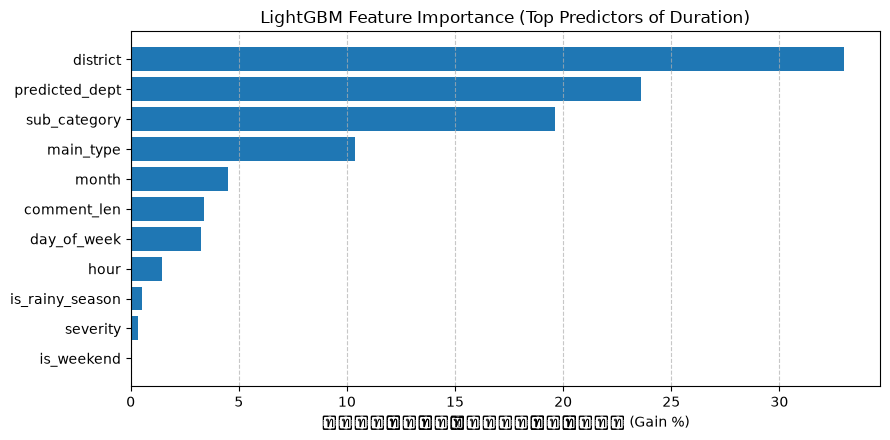

In [18]:
importance_gain = single_model.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({'Feature': feature_cols, 'Gain': importance_gain}).sort_values(by='Gain', ascending=True)
imp_df['Gain_Pct'] = (imp_df['Gain'] / imp_df['Gain'].sum()) * 100

plt.figure(figsize=(9, 4.5))
plt.barh(imp_df['Feature'], imp_df['Gain_Pct'], color='#1f77b4')
plt.xlabel("ความสำคัญต่อการตัดสินใจ (Gain %)")
plt.title("LightGBM Feature Importance (Top Predictors of Duration)")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


---
## 5. [TRAINING] ฝึกสอน Specialized Sub-models (Mixture of Experts)
ฝึกสอนโมเดลเฉพาะทางของ **5 ฝ่ายหลัก** + **1 General Fallback**


In [19]:
TARGET_DEPTS = ['ฝ่ายโยธา', 'ฝ่ายรักษาความสะอาดฯ', 'ฝ่ายเทศกิจ', 'ฝ่ายสิ่งแวดล้อมฯ', 'สำนักการระบายน้ำ']

DEPT_SLUG_MAP = {
    'ฝ่ายโยธา': 'yotha',
    'ฝ่ายรักษาความสะอาดฯ': 'cleanliness',
    'ฝ่ายเทศกิจ': 'thetsakit',
    'ฝ่ายสิ่งแวดล้อมฯ': 'environment',
    'สำนักการระบายน้ำ': 'drainage',
}

def train_specialized_submodel(dept_name, train_sub, val_sub):
    slug = DEPT_SLUG_MAP.get(dept_name, dept_name)
    sub_cat_cols = ['district', 'main_type', 'sub_category']
    sub_feat_cols = ['district', 'main_type', 'sub_category', 'severity', 'comment_len', 'day_of_week', 'is_weekend', 'month', 'is_rainy_season', 'hour']
    
    t_df = train_sub.copy()
    v_df = val_sub.copy()
    
    sub_cats = {}
    for c in sub_cat_cols:
        cats = sorted(list(t_df[c].dropna().unique()))
        t_df[c] = pd.Categorical(t_df[c], categories=cats)
        v_df[c] = pd.Categorical(v_df[c], categories=cats)
        sub_cats[c] = [str(x) for x in cats]
        
    with open(os.path.join(SPECIALIZED_DIR, f"categories_{slug}.json"), "w", encoding="utf-8") as f:
        json.dump(sub_cats, f, ensure_ascii=False, indent=2)
        
    X_tr = t_df[sub_feat_cols]
    y_tr = np.log1p(t_df['duration_days'])
    X_va = v_df[sub_feat_cols]
    y_va = np.log1p(v_df['duration_days'])
    
    tr_data = lgb.Dataset(X_tr, label=y_tr, categorical_feature=sub_cat_cols)
    va_data = lgb.Dataset(X_va, label=y_va, reference=tr_data, categorical_feature=sub_cat_cols)
    
    n_leaves = 63 if dept_name in ['ฝ่ายโยธา', 'general'] else 31
    p = {
        'objective': 'regression_l1', 'metric': 'mae', 'boosting_type': 'gbdt',
        'learning_rate': 0.05, 'num_leaves': n_leaves, 'min_child_samples': 30,
        'subsample': 0.8, 'colsample_bytree': 0.8, 'cat_smooth': 10.0,
        'random_state': 42, 'n_jobs': -1, 'verbose': -1
    }
    
    m = lgb.train(p, tr_data, num_boost_round=800, valid_sets=[tr_data, va_data], callbacks=[lgb.early_stopping(stopping_rounds=35, verbose=False)])
    m.save_model(os.path.join(SPECIALIZED_DIR, f"model_{slug}.txt"))
    return m, sub_cats

print(" เริ่มฝึกสอน Specialized Sub-models...")
trained_submodels = {}
for dept in TARGET_DEPTS:
    tr_s = train_df[train_df['predicted_dept'] == dept]
    va_s = val_df[val_df['predicted_dept'] == dept]
    print(f"  [+] ฝึกสอน: {dept} (Train: {len(tr_s):,} | Val: {len(va_s):,})")
    m, c = train_specialized_submodel(dept, tr_s, va_s)
    trained_submodels[dept] = m

print("  [+] ฝึกสอน: General Fallback Model...")
m_g, c_g = train_specialized_submodel("general", train_df, val_df)
trained_submodels["general"] = m_g

with open(os.path.join(SPECIALIZED_DIR, "dept_map.json"), "w", encoding="utf-8") as f:
    json.dump(DEPT_SLUG_MAP, f, ensure_ascii=False, indent=2)

print("--> [สำเร็จ] ฝึกสอนโมเดลเฉพาะทางครบทั้ง 6 โมเดลเรียบร้อยแล้ว!")


 เริ่มฝึกสอน Specialized Sub-models...
  [+] ฝึกสอน: ฝ่ายโยธา (Train: 49,016 | Val: 12,295)


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)


  [+] ฝึกสอน: ฝ่ายรักษาความสะอาดฯ (Train: 24,123 | Val: 5,655)


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)


  [+] ฝึกสอน: ฝ่ายเทศกิจ (Train: 46,396 | Val: 14,058)


...

  [+] ฝึกสอน: ฝ่ายสิ่งแวดล้อมฯ (Train: 17,704 | Val: 4,828)


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)


  [+] ฝึกสอน: สำนักการระบายน้ำ (Train: 2,340 | Val: 459)
  [+] ฝึกสอน: General Fallback Model...


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  v_df[c] = pd.Categorical(v_df[c], categories=cats)
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\1745488133.py:23: Pandas4Warning: Constructing a Categorica

--> [สำเร็จ] ฝึกสอนโมเดลเฉพาะทางครบทั้ง 6 โมเดลเรียบร้อยแล้ว!


---
## 6. Specialized Router & Predictor Engine 
คลาส `SpecializedBMAPredictor` ทำหน้าที่เป็น Router ส่งงานแยกตามฝ่ายรับผิดชอบ รองรับทั้งเคสเดี่ยว (<2ms) และตารางข้อมูลขนาดใหญ่แบบ Vectorized


In [20]:
class SpecializedBMAPredictor:
    def __init__(self, models_dir: str = SPECIALIZED_DIR):
        self.models_dir = models_dir
        self.models = {}
        self.categories = {}
        self.dept_map = DEPT_SLUG_MAP.copy()
        self.feature_cols = ['district', 'main_type', 'sub_category', 'severity', 'comment_len', 'day_of_week', 'is_weekend', 'month', 'is_rainy_season', 'hour']
        self.cat_cols = ['district', 'main_type', 'sub_category']
        self._load_models()

    def _resolve_slug(self, dept_name: str) -> str:
        s = str(dept_name).strip()
        return self.dept_map.get(s, s if s in self.models else "general")

    def _load_models(self):
        dept_map_path = os.path.join(self.models_dir, "dept_map.json")
        if os.path.exists(dept_map_path):
            with open(dept_map_path, "r", encoding="utf-8") as f:
                self.dept_map.update(json.load(f))
                
        all_slugs = list(set(list(self.dept_map.values()) + ["general"]))
        for slug in all_slugs:
            m_path = os.path.join(self.models_dir, f"model_{slug}.txt")
            c_path = os.path.join(self.models_dir, f"categories_{slug}.json")
            if os.path.exists(m_path):
                self.models[slug] = lgb.Booster(model_file=m_path)
                if os.path.exists(c_path):
                    with open(c_path, "r", encoding="utf-8") as f:
                        self.categories[slug] = json.load(f)

    def is_ready(self) -> bool:
        return len(self.models) > 0

    def predict_single(self, feature_dict: dict, predicted_dept: str) -> dict:
        slug = self._resolve_slug(predicted_dept)
        model = self.models.get(slug) or self.models.get("general")
        cats = self.categories.get(slug, {})
        row_df = pd.DataFrame([feature_dict])
        
        for c in self.cat_cols:
            k_cats = cats.get(c, [])
            val = row_df[c].iloc[0]
            if val not in k_cats:
                row_df[c] = 'ทั่วไป' if 'ทั่วไป' in k_cats else (k_cats[0] if k_cats else val)
            row_df[c] = pd.Categorical(row_df[c], categories=k_cats)
            
        pred_log = model.predict(row_df[self.feature_cols])[0]
        days = float(np.expm1(pred_log))
        return {
            "predicted_days": round(max(0.1, days), 2),
            "model_used": f"Specialized ({predicted_dept})" if slug != "general" else "General Fallback",
            "routed_dept": predicted_dept,
            "model_slug": slug
        }

    def predict_df(self, df: pd.DataFrame) -> pd.DataFrame:
        out_df = df.copy()
        out_df['specialized_pred_days'] = 0.0
        out_df['model_used'] = ''
        
        dept_col = 'predicted_dept' if 'predicted_dept' in out_df.columns else None
        groups = [('general', out_df.index)] if dept_col is None else [(str(k), idxs) for k, idxs in out_df.groupby(dept_col).groups.items()]
        
        for dept_str, idxs in groups:
            slug = self._resolve_slug(dept_str)
            model = self.models.get(slug) or self.models.get("general")
            if model is None: continue
            
            cats = self.categories.get(slug, {})
            sub_df = out_df.loc[idxs, self.feature_cols].copy()
            for c in self.cat_cols:
                sub_df[c] = pd.Categorical(sub_df[c], categories=cats.get(c, []))
                
            preds_log = model.predict(sub_df[self.feature_cols])
            preds_days = np.clip(np.expm1(preds_log), 0.1, None)
            out_df.loc[idxs, 'specialized_pred_days'] = np.round(preds_days, 2)
            out_df.loc[idxs, 'model_used'] = f"Specialized ({dept_str})" if slug != "general" else "General Fallback"
            
        return out_df

predictor = SpecializedBMAPredictor()
print(f"Router พร้อมใช้งาน: {predictor.is_ready()} | รายชื่อโมเดล: {list(predictor.models.keys())}")


Router พร้อมใช้งาน: True | รายชื่อโมเดล: ['thetsakit', 'yotha', 'cleanliness', 'environment', 'drainage', 'general']


---
# CRISP-DM Phase 5: Evaluation (การประเมินประสิทธิภาพและวัดผลเปรียบเทียบโมเดล)
## 7. วัดผลเปรียบเทียบ Head-to-Head บน Test Set (49,010 เคส)
นำ Test Set จริงกลางปี 2024 มาประเมินเปรียบเทียบระหว่าง Single Model vs Specialized Sub-models
วัดผลด้วย MAE, Median AE, R-Squared, และความแม่นยำในกรอบ ±1 วัน (24 ชม.), ±2 วัน, ±3 วัน


In [21]:
test_eval = test_df.copy()
for c in cat_cols:
    test_eval[c] = pd.Categorical(test_eval[c], categories=cat_mappings.get(c, []))

single_preds = np.expm1(single_model.predict(test_eval[feature_cols]))
test_eval['single_pred_days'] = single_preds
test_eval = predictor.predict_df(test_eval)

actual = test_eval['duration_days'].values
s_mae = mean_absolute_error(actual, test_eval['single_pred_days'])
s_med = median_absolute_error(actual, test_eval['single_pred_days'])
p_mae = mean_absolute_error(actual, test_eval['specialized_pred_days'])
p_med = median_absolute_error(actual, test_eval['specialized_pred_days'])

s_acc3 = np.mean(np.abs(actual - test_eval['single_pred_days']) <= 3.0) * 100
p_acc3 = np.mean(np.abs(actual - test_eval['specialized_pred_days']) <= 3.0) * 100

print("=" * 65)
print(" สรุปผลการแข่งขันภาพรวม (Overall Benchmark 49,010 เคส)")
print("=" * 65)
print(f"ตัวชี้วัด                      โมเดลเดี่ยว (Single)   โมเดลเฉพาะทาง (Specialized)")
print(f"1. MAE (คลาดเคลื่อนเฉลี่ย)    :    {s_mae:5.2f} วัน           {p_mae:5.2f} วัน")
print(f"2. Median AE (มัธยฐานคลาดเคลื่อน):  {s_med:5.2f} วัน           {p_med:5.2f} วัน")
print(f"3. ความแม่นยำในกรอบ ±3 วัน    :   {s_acc3:5.2f}%           {p_acc3:5.2f}%")
print("=" * 65)

dept_breakdown = []
for d in TARGET_DEPTS:
    sub = test_eval[test_eval['predicted_dept'] == d]
    if len(sub) == 0: continue
    act = sub['duration_days'].values
    sm = mean_absolute_error(act, sub['single_pred_days'])
    smed = median_absolute_error(act, sub['single_pred_days'])
    pm = mean_absolute_error(act, sub['specialized_pred_days'])
    pmed = median_absolute_error(act, sub['specialized_pred_days'])
    dept_breakdown.append({
        'หน่วยงาน': d, 'เคส': len(sub),
        'Single MAE': round(sm, 2), 'Spec MAE': round(pm, 2),
        'Single MedAE': round(smed, 2), 'Spec MedAE': round(pmed, 2),
        'MAE Diff (%)': round(((sm - pm) / sm) * 100, 2)
    })

pd.DataFrame(dept_breakdown)


C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\439888091.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_eval[c] = pd.Categorical(test_eval[c], categories=cat_mappings.get(c, []))
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\439888091.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_eval[c] = pd.Categorical(test_eval[c], categories=cat_mappings.get(c, []))
C:\Users\thewh\AppData\Local\Temp\ipykernel_37268\439888091.py:3: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  test_eval[c] = pd.Categorical(test_eval[c], categories=cat_mappings.get(c, []))
C:\Users\thewh\AppData\Local

 สรุปผลการแข่งขันภาพรวม (Overall Benchmark 49,010 เคส)
ตัวชี้วัด                      โมเดลเดี่ยว (Single)   โมเดลเฉพาะทาง (Specialized)
1. MAE (คลาดเคลื่อนเฉลี่ย)    :     7.06 วัน            7.08 วัน
2. Median AE (มัธยฐานคลาดเคลื่อน):   3.03 วัน            3.17 วัน
3. ความแม่นยำในกรอบ ±3 วัน    :   49.63%           48.21%


,หน่วยงาน,เคส,Single MAE,Spec MAE,Single MedAE,Spec MedAE,MAE Diff (%)
0,ฝ่ายโยธา,11661,10.31,10.30,5.67,5.71,0.08
1,ฝ่ายรักษาความสะอาดฯ,6830,4.68,4.61,2.09,1.94,1.48
2,ฝ่ายเทศกิจ,13713,4.69,4.63,2.01,1.81,1.16
3,ฝ่ายสิ่งแวดล้อมฯ,4154,7.88,7.78,4.56,4.38,1.28
4,สำนักการระบายน้ำ,495,6.19,6.08,2.68,2.59,1.74


---
# CRISP-DM Phase 6: Deployment (การนำไปประยุกต์ใช้งานจริงและระบบตัดสินใจสั่งการ)
## 8. [TIER 3] Actionable Decision Layer: จัดการ กทม. (BMA Triage Matrix)
ระบบใช้สถิติขนาดพื้นที่และประชากรจริง 50 สำนักงานเขตของ กทม. ในการคำนวณ Public Impact Score:
$$\text{Public Impact Score} = \text{Severity (1-5)} \times \text{Density Factor (1.0-1.5)} \times \text{Predicted Days}$$
จัดกลุ่มปัญหาออกเป็น 4 Quadrants เพื่อส่งคำสั่งการให้เจ้าหน้าที่ กทม. ได้ทันที

### แหล่งอ้างอิงข้อมูลเปิด กทม. (BMA Open Data):
* **URL ดาวน์โหลดทางการ:** [https://data.bangkok.go.th/dataset/1e04f888-6287-41ce-aaa8-91f3bc6dae25/resource/712d9fd9-1d25-401c-a508-3fb49c43e3fb/download/district.csv](https://data.bangkok.go.th/dataset/1e04f888-6287-41ce-aaa8-91f3bc6dae25/resource/712d9fd9-1d25-401c-a508-3fb49c43e3fb/download/district.csv)
* **ไฟล์ข้อมูล:** `district (1).csv`


In [22]:
# ---------------------------------------------------------
# 8.1 การคลีนข้อมูลและคำนวณความหนาแน่นประชากรจาก BMA Open Data
# แหล่งอ้างอิง: https://data.bangkok.go.th/dataset/1e04f888-6287-41ce-aaa8-91f3bc6dae25/resource/712d9fd9-1d25-401c-a508-3fb49c43e3fb/download/district.csv
# ---------------------------------------------------------

# ค้นหาไฟล์ดิบ district (1).csv
district_raw_path = None
for candidate_path in [
    os.path.join(BASE_DIR, "district (1).csv"),
    os.path.join(EXTERNAL_DIR, "district (1).csv"),
    os.path.join(EXTERNAL_DIR, "district.csv"),
    os.path.join(BASE_DIR, "district.csv"),
    r"C:\Users\thewh\Downloads\traffy-fondue-ml\district (1).csv"
]:
    if os.path.exists(candidate_path):
        district_raw_path = candidate_path
        break

if district_raw_path:
    print(f"[+] โหลดข้อมูลดิบสำหรับคลีนจาก: {district_raw_path}")
    raw_district_df = pd.read_csv(district_raw_path)
    
    # 1. คลีนชื่อเขต (ตัดคำว่า 'เขต' ออก และแก้คำสะกดผิดตามราชบัณฑิตยสภา)
    clean_names = []
    for name in raw_district_df['dname']:
        c_name = str(name).replace("เขต", "").strip()
        if c_name == "ราษฏร์บูรณะ":
            c_name = "ราษฎร์บูรณะ"
        clean_names.append(c_name)
    
    # 2. คำนวณประชากรรวม (ชาย + หญิง) และขนาดพื้นที่ (ตร.กม.)
    total_population = raw_district_df['num_male'].astype(int) + raw_district_df['num_female'].astype(int)
    area_sqkm = raw_district_df['area_dis'].astype(float)
    
    # 3. คำนวณความหนาแน่นประชากร (คนต่อตารางกิโลเมตร)
    pop_density = (total_population / area_sqkm).round(1)
    
    # 4. สร้าง Cleaned DataFrame
    cleaned_density_df = pd.DataFrame({
        'dcode': raw_district_df['dcode'],
        'district_th': clean_names,
        'district_en': raw_district_df['dname_e'],
        'num_male': raw_district_df['num_male'],
        'num_female': raw_district_df['num_female'],
        'population': total_population,
        'area_sqkm': area_sqkm.round(2),
        'pop_density': pop_density
    }).sort_values(by='pop_density', ascending=False).reset_index(drop=True)
    
    # 5. บันทึกผลลัพธ์เป็น Master Cleaned CSV
    os.makedirs(EXTERNAL_DIR, exist_ok=True)
    cleaned_density_df.to_csv(DENSITY_FILE, index=False, encoding='utf-8-sig')
    print(f"[DONE] คลีนข้อมูลและคำนวณความหนาแน่นประชากร 50 เขตสำเร็จ: {DENSITY_FILE}")
    print(f"       - จำนวนเขตทั้งหมด: {len(cleaned_density_df)} เขต")
    print(f"       - ประชากรรวมทั้ง กทม.: {total_population.sum():,} คน")
    print(f"       - พื้นที่รวมทั้ง กทม.: {area_sqkm.sum():.2f} ตร.กม.")
    print(f"       - ความหนาแน่นต่ำสุด: {pop_density.min():.1f} คน/ตร.กม. ({cleaned_density_df.iloc[-1]['district_th']})")
    print(f"       - ความหนาแน่นสูงสุด: {pop_density.max():.1f} คน/ตร.กม. ({cleaned_density_df.iloc[0]['district_th']})")
    
    print("\n[5 เขตที่มีความหนาแน่นประชากรสูงสุด (คน/ตร.กม.)]:")
    print(cleaned_density_df[['district_th', 'population', 'area_sqkm', 'pop_density']].head(5).to_string(index=False))
    print("\n[5 เขตที่มีความหนาแน่นประชากรต่ำสุด (คน/ตร.กม.)]:")
    print(cleaned_density_df[['district_th', 'population', 'area_sqkm', 'pop_density']].tail(5).to_string(index=False))
else:
    print(f"[!] ไม่พบไฟล์ raw district (1).csv - โหลดข้อมูลตรงจาก: {DENSITY_FILE}")
    cleaned_density_df = pd.read_csv(DENSITY_FILE)


[+] โหลดข้อมูลดิบสำหรับคลีนจาก: c:\Users\thewh\Downloads\traffy-fondue-ml\data\external\district (1).csv
[DONE] คลีนข้อมูลและคำนวณความหนาแน่นประชากร 50 เขตสำเร็จ: c:\Users\thewh\Downloads\traffy-fondue-ml\data\external\bkk_population_density.csv
       - จำนวนเขตทั้งหมด: 50 เขต
       - ประชากรรวมทั้ง กทม.: 5,494,677 คน
       - พื้นที่รวมทั้ง กทม.: 1568.74 ตร.กม.
       - ความหนาแน่นต่ำสุด: 767.7 คน/ตร.กม. (หนองจอก)
       - ความหนาแน่นสูงสุด: 20357.3 คน/ตร.กม. (ป้อมปราบศัตรูพ่าย)

[5 เขตที่มีความหนาแน่นประชากรสูงสุด (คน/ตร.กม.)]:
      district_th  population  area_sqkm  pop_density
ป้อมปราบศัตรูพ่าย       39310       1.93      20357.3
      สัมพันธวงศ์       20168       1.42      14242.9
           ดินแดง      111052       8.35      13293.3
           ธนบุรี       99591       8.55      11646.7
          คลองสาน       66347       6.05      10964.6

[5 เขตที่มีความหนาแน่นประชากรต่ำสุด (คน/ตร.กม.)]:
district_th  population  area_sqkm  pop_density
  คลองสามวา      209120     110.69     

In [23]:
class BMADecisionLayer:
    """
    Actionable Decision Layer:
    ใช้สถิติความหนาแน่นประชากร 50 เขตที่คำนวณจาก BMA Open Data
    คำนวณ Public Impact Score และจัดกลุ่ม Triage สั่งการ กทม.
    """
    def __init__(self, density_csv_path: str = DENSITY_FILE):
        self.density_csv_path = density_csv_path
        self.density_df = None
        self.density_map = {}
        
        # ตรวจสอบ path ไฟล์ความหนาแน่นประชากร
        target_path = None
        for p in [
            self.density_csv_path,
            os.path.join(EXTERNAL_DIR, "bkk_population_density.csv"),
            os.path.join(os.getcwd(), "data", "external", "bkk_population_density.csv")
        ]:
            if p and os.path.exists(p):
                target_path = p
                break
                
        if target_path:
            self.density_df = pd.read_csv(target_path)
            self.min_density = float(self.density_df["pop_density"].min())
            self.max_density = float(self.density_df["pop_density"].max())
            for _, row in self.density_df.iterrows():
                name_th = str(row["district_th"]).strip()
                clean = name_th.replace("เขต", "").strip()
                density = float(row["pop_density"])
                self.density_map[clean] = density
                self.density_map[f"เขต{clean}"] = density
            print(f"[+] BMADecisionLayer โหลดข้อมูลความหนาแน่นประชากรสำเร็จ ({len(self.density_df)} เขต)")
        else:
            self.min_density = 767.7
            self.max_density = 20357.3
            print(f"[!] ไม่พบไฟล์ {self.density_csv_path} - ใช้ค่าประมาณการ")

    def get_pop_density(self, district: str) -> float:
        clean_d = district.replace("เขต", "").strip() if isinstance(district, str) else ""
        return float(self.density_map.get(clean_d, 5000.0))

    def get_density_factor(self, district: str) -> float:
        d_val = self.get_pop_density(district)
        norm = (d_val - self.min_density) / (self.max_density - self.min_density + 1e-6)
        return float(np.clip(1.0 + 0.5 * norm, 1.0, 1.5))

    def triage_ticket(self, district: str, severity: int, predicted_days: float) -> dict:
        pop_density = self.get_pop_density(district)
        df_factor = self.get_density_factor(district)
        impact_score = severity * df_factor * max(predicted_days, 0.1)
        
        is_severe = severity >= 3
        is_fast = predicted_days <= 5.0
        
        if is_severe and is_fast:
            quadrant = "Critical Urgent"
            action = "สั่งหน่วยเคลื่อนที่เร็วเข้าเคลียร์หน้างานภายใน 24 ชม. ทันที"
        elif is_severe and not is_fast:
            quadrant = "High Impact Project"
            action = "ตั้งงบด่วนหรือระดมช่างข้ามเขตเพื่อลดระยะเวลาซ่อม"
        elif not is_severe and is_fast:
            quadrant = "Quick Win"
            action = "ส่งทีมเขตเข้าเก็บงานทันทีเพื่อเพิ่มคะแนนความพึงพอใจ"
        else:
            quadrant = "Routine Maintenance"
            action = "ส่งเข้าคิวงานซ่อมบำรุงประจำวันตามรอบปกติ"
            
        return {
            "pop_density": round(pop_density, 1),
            "density_factor": round(df_factor, 3),
            "impact_score": round(impact_score, 2),
            "quadrant": quadrant,
            "action": action
        }

    def evaluate_df(self, df: pd.DataFrame, duration_col="specialized_pred_days") -> pd.DataFrame:
        res_df = df.copy()
        scores, quads, acts, densities = [], [], [], []
        for _, row in res_df.iterrows():
            t = self.triage_ticket(str(row.get("district", "")), int(row.get("severity", 3)), float(row[duration_col]))
            densities.append(t["pop_density"])
            scores.append(t["impact_score"])
            quads.append(t["quadrant"])
            acts.append(t["action"])
        res_df["pop_density"] = densities
        res_df["public_impact_score"] = scores
        res_df["triage_quadrant"] = quads
        res_df["bma_action"] = acts
        return res_df

decision_layer = BMADecisionLayer(DENSITY_FILE)
sample_triage = decision_layer.evaluate_df(test_eval.head(1000))
print("\nสัดส่วนปัญหาในแต่ละ Quadrant (1,000 เคสตัวอย่าง):")
print(sample_triage["triage_quadrant"].value_counts())
print("\nตัวอย่าง 5 เคสที่เร่งด่วนและส่งผลกระทบต่อประชาชนสูงสุด:")
print(sample_triage[["ticket_id", "district", "pop_density", "severity", "specialized_pred_days", "public_impact_score", "triage_quadrant"]].sort_values(by="public_impact_score", ascending=False).head(5).to_string(index=False))


[+] BMADecisionLayer โหลดข้อมูลความหนาแน่นประชากรสำเร็จ (50 เขต)

สัดส่วนปัญหาในแต่ละ Quadrant (1,000 เคสตัวอย่าง):
triage_quadrant
Quick Win              466
Routine Maintenance    244
Critical Urgent        149
High Impact Project    141
Name: count, dtype: int64

ตัวอย่าง 5 เคสที่เร่งด่วนและส่งผลกระทบต่อประชาชนสูงสุด:
  ticket_id district  pop_density  severity  specialized_pred_days  public_impact_score     triage_quadrant
     FUYEDF  มีนบุรี       2215.9         3                  29.04                90.34 High Impact Project
     AXPWVW  จตุจักร       4673.4         3                  22.42                73.97 High Impact Project
     HD7T78  จตุจักร       4673.4         3                  22.42                73.97 High Impact Project
2024-9C2KC8  บางซื่อ      10344.8         4                  13.86                68.99 High Impact Project
     AN3B3V    บางแค       4324.6         5                  11.83                64.52 High Impact Project


---
## 9. End-to-End Simulation (ข้อความภาษาไทยสดๆ -> LLM -> AI Model -> Action)
ทดสอบระบบครบ 3 ชั้นแบบสดๆ:
1. **Tier 1 (LLM):** อ่านข้อความดิบ -> สกัด Severity, Sub-category, และ Department
2. **Tier 2 (MoE Model):** Router เลือกโมเดลเฉพาะทาง -> ทำนายวันแล้วเสร็จ
3. **Tier 3 (Decision Layer):** คำนวณ Impact Score -> สั่งการ กทม. ทันที!


In [24]:
def submit_complaint_end_to_end(district: str, main_type: str, raw_comment: str, hour: int = 9):
    print("=" * 70)
    print(" [INPUT] ได้รับเรื่องร้องเรียนใหม่จากประชาชน")
    print("=" * 70)
    print(f"พื้นที่แจ้งเหตุ : เขต{district}")
    print(f"หมวดปัญหาหลัก  : {main_type}")
    print(f"ข้อความประชาชน : '{raw_comment}'")
    
    # 1. LLM Feature Extraction
    print("\n[Step 1] ให้ Local LLM (Ollama / Heuristic) วิเคราะห์ข้อความ...")
    llm_res = analyzer.analyze(raw_comment)
    sev = llm_res["severity"]
    sub_cat = llm_res["sub_category"]
    dept = llm_res["predicted_dept"]
    
    print(f"  -> สกัดความรุนแรง (Severity) : ระดับ {sev}/5")
    print(f"  -> ระบุเนื้องานย่อย (Sub-type) : {sub_cat}")
    print(f"  -> ส่งต่อฝ่ายรับผิดชอบ         : {dept}")
    print(f"  -> เหตุผลประกอบ              : {llm_res['reason']}")
    print(f"  -> Engine ที่ประมวลผล         : {llm_res['engine']}")
    
    # 2. Specialized ML Prediction
    print("\n[Step 2] Route เรื่องเข้าสู่ Specialized Sub-model ประจำหน่วยงาน...")
    payload = {
        'district': district, 'main_type': main_type, 'sub_category': sub_cat,
        'severity': sev, 'comment_len': len(raw_comment), 'day_of_week': 2,
        'is_weekend': 0, 'month': 6, 'is_rainy_season': 1, 'hour': hour
    }
    pred_res = predictor.predict_single(payload, predicted_dept=dept)
    pred_days = pred_res['predicted_days']
    print(f"  -> โมเดลที่ถูกเลือกใช้ : {pred_res['model_used']} (Slug: {pred_res['model_slug']})")
    print(f"  -> คาดการณ์ระยะเวลาซ่อม : {pred_days} วัน (~{pred_days*24:.1f} ชั่วโมง)")
    
    # 3. Actionable Triage Matrix
    print("\n[Step 3] คำนวณ Public Impact Score และจัดกลุ่ม Triage สั่งการ...")
    triage = decision_layer.triage_ticket(district, sev, pred_days)
    print(f"  -> ข้อมูลความหนาแน่นประชากร : {triage['pop_density']:,.1f} คน/ตร.กม. (Density Factor: {triage['density_factor']})")
    print(f"  -> Public Impact Score     : {triage['impact_score']}")
    print(f"  -> กลุ่ม Triage กทม.        : {triage['quadrant']}")
    print(f"  -> คำสั่งการผู้บริหาร กทม.    : {triage['action']}")
    print("=" * 70)

# ทดสอบรันเคสตัวอย่าง 1: ปัญหาวิกฤตอันตรายถึงชีวิต
submit_complaint_end_to_end(
    district="จตุจักร", main_type="ถนน",
    raw_comment="ฝาท่อระบายน้ำหน้าตลาดแตกเปิดอ้ากว้างมาก มอเตอร์ไซค์สะดุดล้มไปแล้วเมื่อเช้า อันตรายถึงชีวิต ช่วยซ่อมด่วนครับ",
    hour=8
)

# ทดสอบรันเคสตัวอย่าง 2: ปัญหาขยะตกค้าง
submit_complaint_end_to_end(
    district="สาทร", main_type="ขยะ",
    raw_comment="มีคนนำขยะชิ้นใหญ่และกิ่งไม้มาทิ้งกองไว้ริมทางเท้า ส่งกลิ่นเหม็นและกีดขวางคนเดิน",
    hour=14
)


 [INPUT] ได้รับเรื่องร้องเรียนใหม่จากประชาชน
พื้นที่แจ้งเหตุ : เขตจตุจักร
หมวดปัญหาหลัก  : ถนน
ข้อความประชาชน : 'ฝาท่อระบายน้ำหน้าตลาดแตกเปิดอ้ากว้างมาก มอเตอร์ไซค์สะดุดล้มไปแล้วเมื่อเช้า อันตรายถึงชีวิต ช่วยซ่อมด่วนครับ'

[Step 1] ให้ Local LLM (Ollama / Heuristic) วิเคราะห์ข้อความ...
  -> สกัดความรุนแรง (Severity) : ระดับ 5/5
  -> ระบุเนื้องานย่อย (Sub-type) : ฝาท่อชำรุด
  -> ส่งต่อฝ่ายรับผิดชอบ         : สำนักการระบายน้ำ
  -> เหตุผลประกอบ              : ประเมินโดย Heuristic Engine
  -> Engine ที่ประมวลผล         : fast_heuristic

[Step 2] Route เรื่องเข้าสู่ Specialized Sub-model ประจำหน่วยงาน...
  -> โมเดลที่ถูกเลือกใช้ : Specialized (สำนักการระบายน้ำ) (Slug: drainage)
  -> คาดการณ์ระยะเวลาซ่อม : 4.65 วัน (~111.6 ชั่วโมง)

[Step 3] คำนวณ Public Impact Score และจัดกลุ่ม Triage สั่งการ...
  -> ข้อมูลความหนาแน่นประชากร : 4,673.4 คน/ตร.กม. (Density Factor: 1.1)
  -> Public Impact Score     : 25.57
  -> กลุ่ม Triage กทม.        : Critical Urgent
  -> คำสั่งการผู้บริหาร กทม.    : สั่งหน่